# Hệ thống Hỏi đáp Luật Giao thông Việt Nam
## Model + Fine-tuning (QLoRA)

**Model:** `Qwen/Qwen2.5-1.5B-Instruct`  
**Phương pháp:** QLoRA (4-bit + LoRA)  
**Dataset:** `kwnn/traffic-law-qa-vietnamese`   
**Lưu checkpoint:** Google Drive  

---
## RAG + Evalution + Demo
ghi ra gì gì đó

## 1. Mount Google Drive

In [36]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Tạo thư mục lưu checkpoint trên Drive
DRIVE_SAVE_DIR = "/content/drive/MyDrive/NLP_Project_FinalTerm/checkpoints"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

print(f" Đã mount Drive!")
print(f" Checkpoint sẽ lưu tại: {DRIVE_SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Đã mount Drive!
 Checkpoint sẽ lưu tại: /content/drive/MyDrive/NLP_Project_FinalTerm/checkpoints


## 2. Cài đặt thư viện

In [37]:
%%capture
!pip install -q \
    transformers==4.46.3 \
    datasets \
    peft \
    trl \
    bitsandbytes \
    accelerate


## 3. Load và Format Dataset

In [38]:
from datasets import load_dataset

dataset = load_dataset("kwnn/traffic-law-qa-vietnamese")
print(dataset)
print("\n--- Ví dụ 1 sample ---")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['chunk_id', 'context', 'question', 'answer', 'source', 'type'],
        num_rows: 330
    })
    test: Dataset({
        features: ['chunk_id', 'context', 'question', 'answer', 'source', 'type'],
        num_rows: 51
    })
})

--- Ví dụ 1 sample ---
{'chunk_id': 'luat trật tự_273', 'context': '8. Bộ trưởng Bộ Giao thông vận tải quy định hình thức, nội dung, chương trình đào tạo lái xe, thời gian lái xe an toàn cho từng hạng giấy phép lái xe quy định tại khoản 4 Điều này và quy định tiêu chuẩn của cơ sở đào tạo lái xe mô tô; đối với cơ sở đào tạo, tổ chức đào tạo lái xe cho lực lượng quân đội, công an làm nhiệm vụ quốc phòng, an ninh do Bộ trưởng Bộ Quốc phòng, Bộ trưởng Bộ Công an quy định.', 'question': 'Ai quy định tiêu chuẩn của cơ sở đào tạo lái xe mô tô cho lực lượng quân đội, công an?', 'answer': 'Bộ trưởng Bộ Quốc phòng, Bộ trưởng Bộ Công an', 'source': 'luat trật tự', 'type': 'direct'}


In [39]:
# System Prompt đóng vai trò định hướng hành vi mô hình
SYSTEM_PROMPT = "Bạn là trợ lý pháp lý chuyên về luật giao thông đường bộ Việt Nam. Hãy trả lời câu hỏi dựa trên văn bản pháp luật được cung cấp một cách chính xác."

def format_instruction(sample):
    """Định dạng dữ liệu theo cấu trúc ChatML"""
    # Xử lý trường hợp không có context để phục vụ thực nghiệm C
    context = sample.get('context', "Không có văn bản đính kèm.")

    text = f"""<|im_start|>system
{SYSTEM_PROMPT}<|im_end|>
<|im_start|>user
Văn bản pháp luật:
{context}

Câu hỏi: {sample['question']}<|im_end|>
<|im_start|>assistant
{sample['answer']}<|im_end|>"""
    return {"text": text}

# Áp dụng format và chia tập Validation (10%) để theo dõi Overfitting
dataset_formatted = dataset["train"].map(format_instruction)
split_data = dataset_formatted.train_test_split(test_size=0.1, seed=42)

train_data = split_data["train"]
val_data = split_data["test"]

## 4. Load Model với 4-bit Quantization

In [40]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# 1. Cấu hình Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# 2. Load Tokenizer & Model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

# 3. Chuẩn bị mô hình cho PEFT
model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

# Đảm bảo model nằm trên GPU
model.to("cuda")

model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 5. Training

In [41]:
from transformers import EarlyStoppingCallback

# 1. Cấu hình Training - Chỉ giữ lại 1 bản duy nhất
training_args = SFTConfig(
    output_dir="./results",
    num_train_epochs=15,               # Bạn cứ để cao, Early Stopping sẽ tự dừng
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    max_seq_length=1024,

    # --- CẤU HÌNH LƯU TRỮ TỐI ƯU ---
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=True,
    logging_steps=10,
    dataset_text_field="text",
    report_to="none",
)

# 2. Khởi tạo Trainer với Early Stopping
trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    args=training_args,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Dừng nếu 2 epoch không tiến triển
)

# 3. Chạy Training
trainer.train()

FINAL_DRIVE_PATH = "/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final"
trainer.save_model(FINAL_DRIVE_PATH)
tokenizer.save_pretrained(FINAL_DRIVE_PATH)


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
0,1.211300,0.801529
1,0.735100,0.699903
2,0.559600,0.617919
3,0.391600,0.578556
4,0.277700,0.561586
5,0.231700,0.558680
6,0.125300,0.566456
7,0.088700,0.574331


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

('/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/special_tokens_map.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/vocab.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/merges.txt',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/added_tokens.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/tokenizer.json')

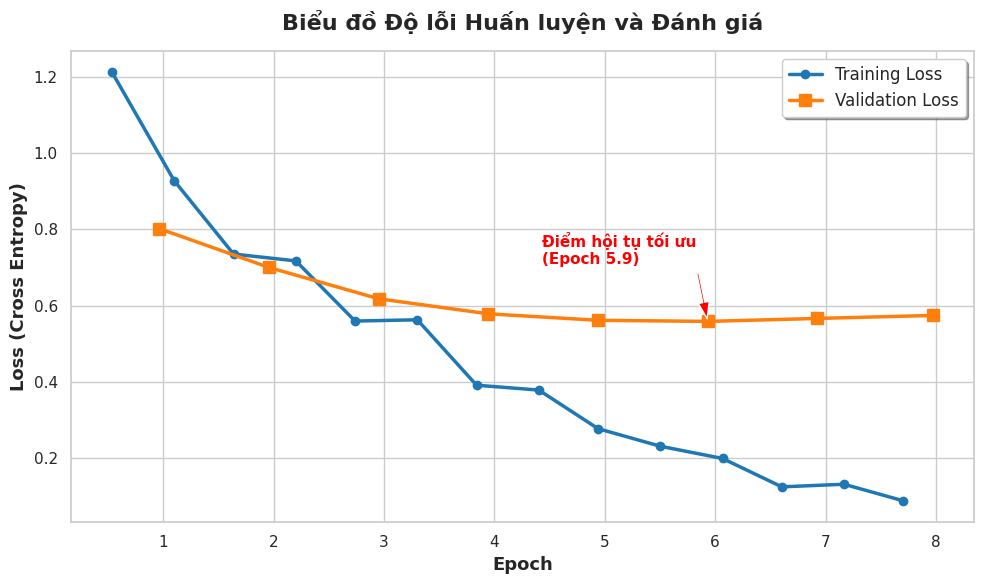

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TRÍCH XUẤT DỮ LIỆU THẬT TỪ TRAINER
log_history = trainer.state.log_history

train_epochs = []
train_loss = []
val_epochs = []
val_loss = []

# Duyệt qua các bản ghi log để lấy số liệu
for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_epochs.append(log['epoch'])
        train_loss.append(log['loss'])
    elif 'eval_loss' in log and 'epoch' in log:
        val_epochs.append(log['epoch'])
        val_loss.append(log['eval_loss'])

# 2. VẼ BIỂU ĐỒ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Vẽ 2 đường Loss dựa trên dữ liệu tự động
plt.plot(train_epochs, train_loss, label='Training Loss', color='#1f77b4', marker='o', linewidth=2.5, markersize=6)
plt.plot(val_epochs, val_loss, label='Validation Loss', color='#ff7f0e', marker='s', linewidth=2.5, markersize=8)

# Tìm epoch có validation loss thấp nhất để đánh dấu (Điểm hội tụ tốt nhất)
best_epoch_idx = val_loss.index(min(val_loss))
best_epoch = val_epochs[best_epoch_idx]
best_loss = val_loss[best_epoch_idx]

plt.annotate(f'Điểm hội tụ tối ưu\n(Epoch {best_epoch:.1f})',
             xy=(best_epoch, best_loss), xytext=(best_epoch - 1.5, best_loss + 0.15),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, color='red', fontweight='bold')

# Tiêu đề và nhãn trục
plt.title('Biểu đồ Độ lỗi Huấn luyện và Đánh giá', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.ylabel('Loss (Cross Entropy)', fontsize=13, fontweight='bold')

plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)

# Hiển thị và lưu ảnh
plt.tight_layout()
plt.savefig('loss_curve_traffic_law_auto.png', dpi=300)
plt.show()


### 📊 Phân tích Kết quả Huấn luyện

Quá trình tinh chỉnh mô hình Qwen2.5-1.5B với cấu hình Early Stopping đã diễn ra thành công và thể hiện rõ tính quy luật của Machine Learning:

1. **Điểm hội tụ lý tưởng:** Mô hình đạt trạng thái tốt nhất tại **Epoch 5** với Validation Loss ghi nhận mức thấp nhất là `0.5586` và Training Loss đạt `0.2317`.
2. **Phát hiện Overfitting:** Từ Epoch 6 và Epoch 7, Validation Loss bắt đầu có dấu hiệu tăng ngược trở lại (`0.5664` và `0.5743`), biểu hiện của việc mô hình bắt đầu học vẹt (overfit) dữ liệu huấn luyện.
3. **Hiệu quả của Early Stopping:** Nhờ cơ chế theo dõi độ trễ (patience=2), hệ thống đã tự động nhận diện được sự suy giảm chất lượng và dừng huấn luyện kịp thời. Mô hình cuối cùng được xuất ra (`best_model_final`) đã tự động khôi phục lại trọng số của Epoch 5, đảm bảo hệ thống RAG sở hữu phiên bản ngôn ngữ có khả năng tổng quát hóa pháp lý cao nhất.